In [1]:
import matplotlib.pyplot as plt

In [2]:
from LIMxCMBL.init import *
from LIMxCMBL.noise import *
from scipy.signal.windows import dpss
import sys
Lambda_idx = 18#int(sys.argv[1])
nbins = 100#int(sys.argv[2])

Lambda = Lambdas[Lambda_idx]
print(Lambda)

zmin = 3.5#float(sys.argv[3])
zmax = 8.1#float(sys.argv[4])

chimin = ccl.comoving_angular_distance(cosmo, 1/(1+zmin))
chimax = ccl.comoving_angular_distance(cosmo, 1/(1+zmax))


oup_fname = '/scratch/users/delon/LIMxCMBL/eHIeHI/comb_zmin_%.5f_zmax_%.5f_Lambda_idx_%.d_from_quad_nbins_%d.npy'%(zmin, zmax, Lambda_idx, nbins)
print(oup_fname)


chi_bin_edges = np.linspace(chimin*(1+1e-8), chimax*(1 - 1e-8), nbins + 1)
eHIeHI_binned = np.zeros((nbins,nbins), dtype=np.float128)
dchi = np.mean(np.diff(chi_bin_edges))

0.01
/scratch/users/delon/LIMxCMBL/eHIeHI/comb_zmin_3.50000_zmax_8.10000_Lambda_idx_18_from_quad_nbins_100.npy


In [3]:
import scipy

In [4]:
def get_mathematica(fname, to_scipy=False):
    _f_mathematica = None
    with open(fname, 'r') as f:
        _f_mathematica = f.read()
    _f_mathematica = _f_mathematica.replace('\[Pi]', 'Pi')
    _f_sympy = parse_mathematica(_f_mathematica)
    return _f_sympy

In [5]:
m_for_LO = 0
while(m_for_LO * 2 * np.pi / (chimax - chimin) < Lambda):
    m_for_LO += 1
m_for_LO -= 1

In [6]:
import os
_f_eLOeLO_tot = None
for a in range(-m_for_LO, m_for_LO+1):
    for b in range(-m_for_LO, m_for_LO+1):
        print(a, b)
        _a = np.abs(a)
        _b = np.abs(b)
        _full_fname =  '008.023.mathematica/008.023.eLOeLO_summand_%d_%d_.txt'%(_a, _b)
        _f = get_mathematica(_full_fname)
        if(_f_eLOeLO_tot is None):
            _f_eLOeLO_tot = _f
        else:
            _f_eLOeLO_tot += _f

-3 -3
-3 -2
-3 -1
-3 0
-3 1
-3 2
-3 3
-2 -3
-2 -2
-2 -1
-2 0
-2 1
-2 2
-2 3
-1 -3
-1 -2
-1 -1
-1 0
-1 1
-1 2
-1 3
0 -3
0 -2
0 -1
0 0
0 1
0 2
0 3
1 -3
1 -2
1 -1
1 0
1 1
1 2
1 3
2 -3
2 -2
2 -1
2 0
2 1
2 2
2 3
3 -3
3 -2
3 -1
3 0
3 1
3 2
3 3


In [8]:
# modules = [
#         {
#             'Ci': mpm.ci,
#             'Si': mpm.si,
#             'Cos': mpm.cos,
#             'Sin': mpm.sin,
#             'Log': mpm.log,
#             'Ei': mpm.ei,
#             'I': 1j,},
#         'mpmath']

from scipy import special
def SinIntegral(x):
    si, _ = special.sici(x)
    return si

def CosIntegral(x):
    _, ci = special.sici(x)
    return ci

modules = [
        {
            'Ci': CosIntegral,
            'Si': SinIntegral,
            'Cos': np.cos,
            'Sin': np.sin,
            'Log': np.log,
            'Ei': special.expi,
            'I': 1j,},
        'scipy']

f_eLOeLO_tot = lambdify(list(_f_eLOeLO_tot.free_symbols), _f_eLOeLO_tot, modules=modules)

In [9]:
from scipy.integrate import quad, dblquad, nquad
# from LIMxCMBL.kernels import lo_DFT

# DFT low pass
def lo_DFT_mpmath(alpha):
    _L = chimax - chimin
    #can ignore alpha ~ L due to binning
    if(alpha == 0):# or np.abs(alpha / _L - 1) < 1e-10 or np.abs(alpha / _L + 1) < 1e-10):
        return (1 + 2 * m_for_LO) / (chimax- chimin)
    return mpm.sin(mpm.pi/_L * alpha * (1 + 2 * m_for_LO)) / mpm.sin(mpm.pi/_L * alpha) * 1/_L



# DFT low pass
def lo_DFT(alpha):
    _L = chimax - chimin
    #can ignore alpha ~ L due to binning
    if(alpha == 0):
        return (1 + 2 * m_for_LO) / (chimax- chimin)
    return np.sin(np.pi/_L * alpha * (1 + 2 * m_for_LO)) / np.sin(np.pi/_L * alpha) * 1/_L

In [10]:
(1 + 2 * m_for_LO) / (chimax- chimin)

0.003168083167980179

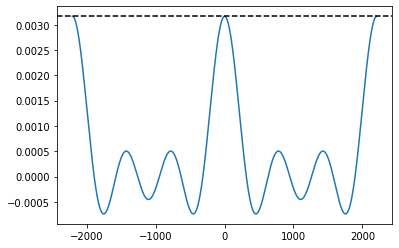

In [11]:
_alphas = np.linspace(-(chimax-chimin) * (1 - 1e-8), (chimax-chimin) * (1 - 1e-8), 10000+1)
plt.plot(_alphas, [lo_DFT_mpmath(_a) for _a in _alphas])
plt.axhline( (1 + 2 * m_for_LO) / (chimax- chimin), c='k', ls='--')

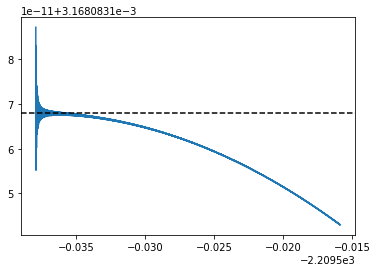

In [12]:
_alphas = np.linspace(-(chimax-chimin) * (1 - 1e-8), -(chimax-chimin)*(1-1e-5), 10000+1)
plt.plot(_alphas, [lo_DFT_mpmath(_a) for _a in _alphas])

plt.axhline( (1 + 2 * m_for_LO) / (chimax- chimin), c='k', ls='--')

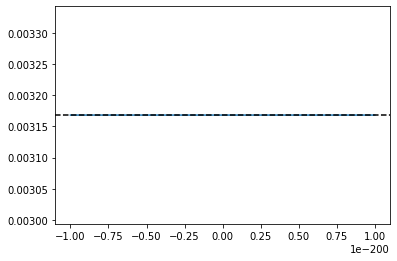

In [13]:
_alphas = np.linspace(-1e-200, 1e-200, 10000+1)
plt.plot(_alphas, [lo_DFT_mpmath(_a) for _a in _alphas])
plt.axhline( (1 + 2 * m_for_LO) / (chimax- chimin), c='k', ls='--')

In [14]:
def compute_bin_element(params):
    i, j, l1, r1, l2, r2, dchi, Lambda, chimin, chimax = params
    eIeI = 0
    if i == j:
        eIeI = 1 / dchi**2 * (1 / l1 - 1 / r1)
    
    
    
    def integrand(x, xp):
        _f_cross = lambda chi, chip : (1/chi**2  * lo_DFT(chi-chip) + 1/chip**2  * lo_DFT(chip-chi))
        return f_eLOeLO_tot(chi = x, chip = xp, chimin = chimin, chimax = chimax) - _f_cross(chi = x, chip = xp)    

    options1 = {'limit':100000, 'epsabs':0.0, 'epsrel':1e-8, 
                'points':(l1, (l1+r1)/2, r1)}
    options2 = {'limit':100000, 'epsabs':0.0, 'epsrel':1e-8, 
                'points':(l2, (l2+r2)/2, r2)}
    

    LOLO_m_cross, _ = nquad(integrand, [[l1, r1],[l2, r2]],
                   opts=[options1,options2])
    
    
#     LOLO_m_cross = mpm.quad(integrand, 
#                             [l1, r1], 
#                             [l2, r2], )
    
    
    LOLO_m_cross = LOLO_m_cross / dchi**2
    
    return (i, j, eIeI + LOLO_m_cross)

In [15]:
params_list = []
for i, (l1, r1) in enumerate(zip(chi_bin_edges[:-1], chi_bin_edges[1:])):
    for j, (l2, r2) in enumerate(zip(chi_bin_edges[:-1], chi_bin_edges[1:])):
        if(j < i):
            continue
        params = (i, j, l1, r1, l2, r2, dchi, Lambda, chimin, chimax)
        params_list.append(params)

In [16]:
compute_bin_element(params_list[600])

(6, 21, 4.578929527577415e-12)

In [17]:
with Pool(processes=32) as pool:
        results = list(tqdm(
            pool.imap(compute_bin_element, params_list),
            total=len(params_list)
        ))

100%|██████████| 5050/5050 [02:04<00:00, 40.71it/s]


In [18]:
import pickle

# with open(oup_fname+'_results.pkl', 'wb') as f:
#     print(oup_fname+'_results.pkl')
#     pickle.dump(results, f)
# print('outputted')


for i, j, value in results:
    eHIeHI_binned[i, j] = eHIeHI_binned[j, i] = np.real(value)

# np.save(oup_fname, eHIeHI_binned)
# print('binned eHIeHI outputed to', oup_fname)

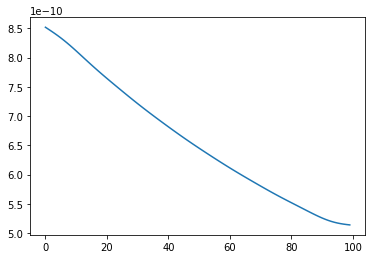

In [19]:
plt.plot(np.diag(eHIeHI_binned))

In [20]:
import numpy as np

def covariance_to_correlation(covariance_matrix):
    variances = np.diag(covariance_matrix)
    if np.any(variances < 0):
        raise ValueError("negative variances")
    std_devs = np.sqrt(variances)
    
    inv_std_devs = 1 / std_devs
    D_inv = np.diag(inv_std_devs)
    correlation_matrix = D_inv @ covariance_matrix @ D_inv
    np.fill_diagonal(correlation_matrix, 1.0)
    
    return correlation_matrix

/share/software/user/open/py-jupyter/1.0.0_py39/lib/python3.9/site-packages/IPython/core/events.py:89: UserWarning: Casting input data from float128 to float64 for imshow.
  func(*args, **kwargs)
/share/software/user/open/py-jupyter/1.0.0_py39/lib/python3.9/site-packages/IPython/core/pylabtools.py:134: UserWarning: Casting input data from float128 to float64 for imshow.
  fig.canvas.print_figure(bytes_io, **kw)


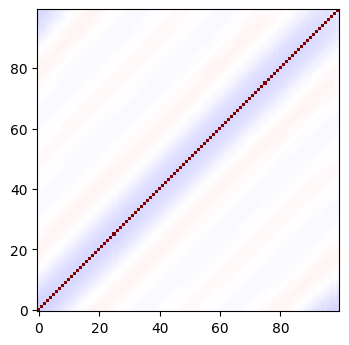

In [21]:
plt.figure(dpi = 100)
plt.imshow(covariance_to_correlation(eHIeHI_binned), 
           vmin = -1,
           vmax = 1,
           cmap = 'seismic',
             interpolation = 'none',
             origin = 'lower')

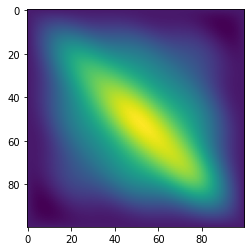

In [22]:
plt.imshow(np.linalg.inv(eHIeHI_binned.astype(np.float64)))

In [23]:
from scipy.linalg import eigvals


eigenvalues, eigenvectors = np.linalg.eig(eHIeHI_binned.astype(np.float64))
patched_eigenvalues = np.where(eigenvalues <1e-10, 0.0, eigenvalues)
patched_cov = eigenvectors @ np.diag(patched_eigenvalues) @ eigenvectors.T

print( np.linalg.cond(np.float64(eHIeHI_binned)))
print( np.linalg.cond(np.float64(patched_cov)))

print(eigenvalues)
np.sum(eigenvalues < 0)

17942734.224450644
4.919985864174269e+16
[2.14072228e-12 2.07757673e-12 9.41463296e-13 9.01005513e-13
 5.17118285e-17 2.19797740e-13 2.39881681e-13 9.27851597e-10
 9.21313219e-10 9.14997023e-10 9.08810323e-10 9.02721600e-10
 8.96715808e-10 8.90784366e-10 8.84921788e-10 8.79124267e-10
 8.73388986e-10 8.67713754e-10 8.62096794e-10 8.56536617e-10
 8.51031936e-10 8.45581615e-10 8.40184632e-10 8.34840049e-10
 8.29546998e-10 8.24304666e-10 8.19112285e-10 8.13969122e-10
 8.08874476e-10 5.40357057e-10 8.03827674e-10 5.43332750e-10
 7.98828065e-10 5.46251453e-10 7.93875018e-10 5.49157694e-10
 7.88967919e-10 7.84106173e-10 7.79289197e-10 5.52066586e-10
 5.54985305e-10 5.57917914e-10 7.74516422e-10 5.60866988e-10
 7.69787292e-10 7.65101262e-10 5.63834299e-10 5.66821144e-10
 7.60457798e-10 5.69828526e-10 5.72857251e-10 7.55856376e-10
 7.51296482e-10 7.46777611e-10 5.75907993e-10 5.78981333e-10
 5.82077786e-10 7.42299266e-10 5.85197817e-10 7.37860959e-10
 5.88341855e-10 7.33462209e-10 5.91510302e-1

0

In [24]:
(chimin+chimax)/2 / dchi

365.16703253440863

In [25]:
Q, R, perm = scipy.linalg.qr(eHIeHI_binned.astype(np.float64), pivoting=True)
print(scipy.linalg.norm(eHIeHI_binned.astype(np.float64)[:, perm] - Q.dot(R), 2), 
      scipy.linalg.norm(Q.dot(Q.T) - np.eye(nbins)))
print([_R for _R in np.diag(R)], end=', ')

1.2036734776604022e-24 7.889728761792297e-15
[-8.840587501890235e-10, -8.757217154822948e-10, -8.671908352536225e-10, -8.584926633140722e-10, -8.496547408646166e-10, -8.407042596635611e-10, 8.324302587315152e-10, 8.26001751078471e-10, 8.200658945546967e-10, 8.13898851995341e-10, 8.074513765965103e-10, 8.00693593212167e-10, 7.936150473083955e-10, 7.863435073740438e-10, -7.81022081635207e-10, 7.784913689677754e-10, 7.728968839518547e-10, -7.669134232390377e-10, 7.605803500443698e-10, 7.53945183768078e-10, 7.47057433495157e-10, 7.403356299689048e-10, 7.370373767065892e-10, 7.340486744813638e-10, 7.290435919088424e-10, -7.236556725282651e-10, 7.178908048835261e-10, 7.163841193374095e-10, 7.11083103555619e-10, 7.048763240553668e-10, -6.990170246947856e-10, 6.944790946611565e-10, 6.926823584960028e-10, -6.876946630712155e-10, 6.823892523730173e-10, 6.768043993985113e-10, 6.709816766161348e-10, -6.687558252997009e-10, 6.651553823963885e-10, 6.607039730742315e-10, -6.600263764134151e-10, 6.553

In [28]:
mpmath_LIDX16_nb100_CCAT = [-8.840587501890233e-10, -8.757217154822946e-10, -8.671908352536224e-10, -8.584926633140724e-10, -8.496547408646167e-10, -8.407042596635613e-10, 8.324302587315151e-10, 8.260017510784711e-10, 8.200658945546968e-10, 8.138988519953411e-10, 8.074513765965101e-10, 8.006935932121674e-10, 7.936150473083953e-10, 7.863435073740439e-10, -7.810220816352067e-10, 7.784913689677751e-10, 7.728968839518548e-10, -7.669134232390379e-10, 7.605803500443701e-10, 7.539451837680777e-10, 7.470574334951565e-10, 7.40335629968905e-10, 7.370373767065897e-10, 7.34048674481364e-10, 7.290435919088425e-10, -7.23655672528265e-10, 7.178908048835261e-10, 7.163841193374101e-10, 7.110831035556192e-10, 7.048763240553669e-10, -6.990170246947855e-10, 6.94479094661156e-10, 6.926823584960025e-10, -6.876946630712155e-10, 6.823892523730172e-10, 6.768043993985113e-10, 6.709816766161347e-10, -6.687558252997013e-10, 6.651553823963885e-10, 6.607039730742317e-10, -6.600263764134153e-10, 6.553627183333371e-10, -6.502665883183532e-10, 6.447730866418307e-10, -6.389349266133542e-10, 6.328609254285488e-10, 6.30606579641643e-10, -6.273169682906173e-10, 6.226651659923919e-10, -6.183827868094287e-10, 6.174328488351252e-10, 6.141388306727783e-10, -6.097776266308018e-10, -6.067955162773406e-10, 6.046590560437822e-10, -5.994324446450647e-10, 5.939007814641304e-10, 5.90354785188457e-10, 5.888825797468358e-10, 5.843046616306653e-10, 5.800184705775544e-10, -5.759881465719623e-10, -5.718005529848573e-10, -5.698941569562846e-10, 5.69577933135166e-10, 5.673296715418232e-10, 5.625764008222388e-10, -5.578749628348177e-10, 5.529836352282858e-10, 5.525459168723637e-10, 5.48426698317149e-10, 5.441454889552489e-10, 5.401832692735159e-10, 5.364347960255771e-10, 5.340291537337997e-10, -5.322713306215603e-10, -5.281017142720793e-10, 5.23555101254797e-10, -5.198034414406516e-10, 5.178877525057385e-10, -5.124337096899033e-10, 5.113017468366289e-10, 5.033806183951589e-10, -4.960006634831614e-10, 4.921963540203967e-10, -4.798669868485772e-10, 4.771766248593462e-10, 4.723588367246523e-10, 4.66883702140004e-10, 4.49887690988446e-10, 4.413408733386097e-10, -4.110698595578605e-10, 3.8900468295428183e-10, -5.484917474629197e-12, 5.1016080568019245e-12, -3.833366769528014e-12, 2.389112115553798e-12, 1.2134089503690498e-12, -8.291138871066119e-13, 5.169301113729898e-16]

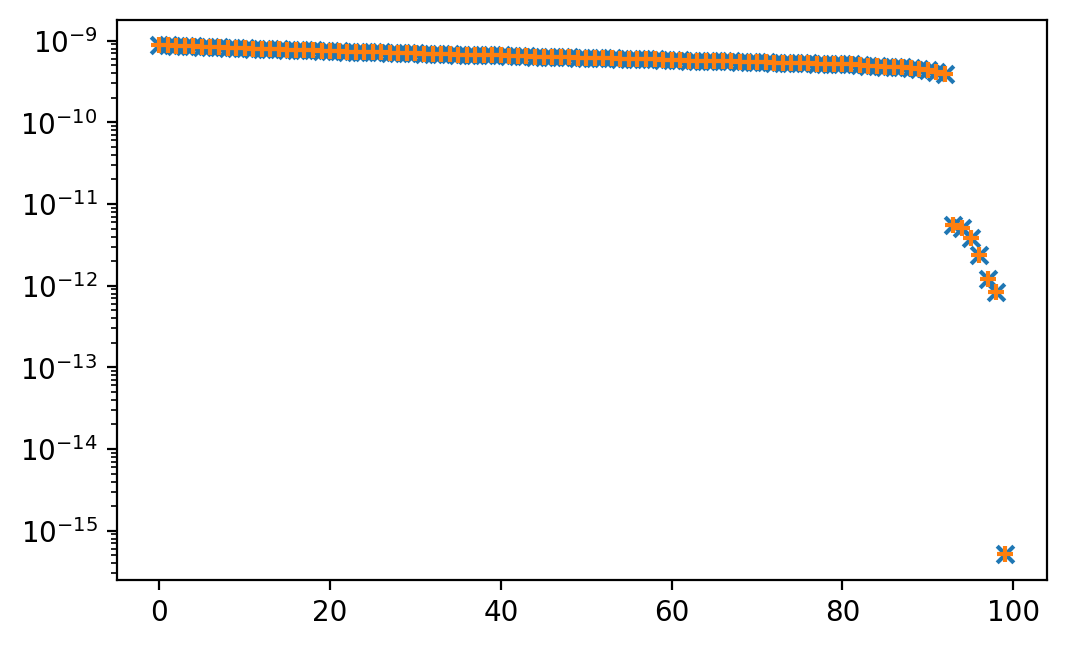

In [29]:
plt.figure(dpi=200, figsize=(6,6/1.618))

plt.scatter(np.arange(100), np.abs(np.diag(R)), marker='x')
plt.scatter(np.arange(100), np.abs(mpmath_LIDX16_nb100_CCAT), marker='+')

plt.yscale('log')

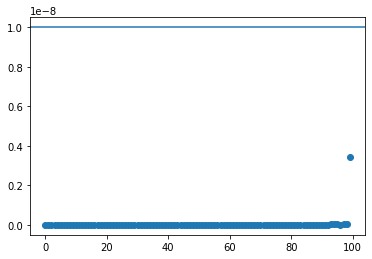

In [36]:
plt.scatter(np.arange(100), np.abs(
    (np.diag(R)-np.array(mpmath_LIDX16_nb100_CCAT)) / np.array(mpmath_LIDX16_nb100_CCAT)
))
plt.axhline(1e-8)

# analytical mean removed

In [ ]:
1/l1 - 1/r1 * 1/ dchi**2

In [ ]:
L = chimax - chimin

In [ ]:
def f_analytical_mean_removed(l1, r1, l2, r2):
    ret = 1/L**2 * (1/chimin - 1/chimax) - 1 / L / dchi * (1/l1 + 1/l2 - 1/r1 - 1/r2)
    if(l1 == l2):
        ret += 1/dchi**2*(1/l1 - 1/r1)
    return ret

In [ ]:
analytical_mean_removed = np.zeros((nbins, nbins))

for i,(l1, r1) in enumerate(zip(chi_bin_edges[:-1], chi_bin_edges[1:])):
    for j,(l2, r2) in enumerate(zip(chi_bin_edges[:-1], chi_bin_edges[1:])):
        analytical_mean_removed[i,j] = f_analytical_mean_removed(l1, r1, l2, r2)

In [ ]:
plt.figure(dpi = 100)
plt.imshow(covariance_to_correlation(analytical_mean_removed), 
           vmin = -1,
           vmax = 1,
           cmap = 'seismic',
             interpolation = 'none',
             origin = 'lower')

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(analytical_mean_removed)
patched_eigenvalues = np.where(eigenvalues <1e-11, 0.0, eigenvalues)
patched_analytical_mean_removed = eigenvectors @ np.diag(patched_eigenvalues) @ eigenvectors.T

In [ ]:
plt.plot(np.diag(analytical_mean_removed))
plt.plot(np.diag(patched_analytical_mean_removed), ls='--')

In [ ]:
plt.figure(dpi = 200)
plt.imshow(covariance_to_correlation(patched_analytical_mean_removed), 
           vmin = -1,
           vmax = 1,
           cmap = 'seismic',
             interpolation = 'none',
             origin = 'lower')

In [ ]:
eIeI = np.diag(f_eIeI(chi_bin_edges[:-1], chi_bin_edges[1:], dchi))
eIeI_eigv, _ = np.linalg.eig(eIeI.astype(np.float64))
analytical_eigv = 1/dchi**2 * (1/chi_bin_edges[:-1] - 1/chi_bin_edges[1:])

print(np.linalg.cond(eIeI))
print(eIeI_eigv - analytical_eigv)
plt.plot(eIeI_eigv)
plt.scatter(np.arange(nbins), analytical_eigv, marker='+')

In [ ]:
Q, R, perm = scipy.linalg.qr(analytical_mean_removed, pivoting=True)
print(scipy.linalg.norm(analytical_mean_removed[:, perm] - Q.dot(R), 2), 
      scipy.linalg.norm(Q.dot(Q.T) - np.eye(nbins)))
print(np.diag(R))

In [ ]:
#     options1 = {'limit':100000, 'epsabs':0.0, 'epsrel':1e-8, 
#                 'points':(l1, (l1+r1)/2, r1)}
#     options2 = {'limit':100000, 'epsabs':0.0, 'epsrel':1e-8, 
#                 'points':(l2, (l2+r2)/2, r2)}
    
#     options3 = {'limit':100000, 'epsabs':0.0, 'epsrel': 1e-3, 
#                 'points':(chimin, l1, l2, (l1+r1)/2, (l2+r2)/2, r1, r2, chimax)}


#     LOLO_m_cross, _ = nquad(integrand, [[l1, r1],[l2, r2]],
#                    opts=[options1,options2])
    
    
